In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [80]:
wdi = pd.read_csv("World development Indicators Data.csv")
column_names_climate = ['Year','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec',
    'J-D','D-N','DJF','MAM','JJA','SON']
climate = pd.read_csv("Nasa_climate_data.csv",skiprows=2,sep=',',header=None,names=column_names_climate)
rli = pd.read_csv("red-list-index.csv")
print("WDI shape:", wdi.shape)
print("Climate shape:", climate.shape)
print("RLI shape:", rli.shape)

WDI shape: (95, 29)
Climate shape: (147, 19)
RLI shape: (8320, 4)


In [81]:
#  WDI DATA PREPARATION
# Standardise year column names
year_cols = [col for col in wdi.columns if "[" in col]
new_year_cols = {col: col.split(" ")[0] for col in year_cols}
wdi = wdi.rename(columns=new_year_cols)
wdi = wdi.rename(columns={"Country Name": "country","Country Code": "country_code","Series Name": "indicator","Series Code": "indicator_code"})
# Convert wide format to long format
wdi_long = wdi.melt(id_vars=["country","country_code","indicator","indicator_code"],var_name="year",value_name="value")
# Remove metadata rows
wdi_long = wdi_long[wdi_long["country"].notna()]
wdi_long = wdi_long[~wdi_long["country"].str.contains("Data from|Last Updated",case=False,na=False)]
# Convert data types
wdi_long["year"] = pd.to_numeric(wdi_long["year"],errors="coerce")
# Replace World Bank missing symbol
wdi_long["value"] = wdi_long["value"].replace("..", np.nan)
wdi_long["value"] = pd.to_numeric(wdi_long["value"], errors="coerce")
print("Missing values:", wdi_long["value"].isna().sum())
print("Shape after conversion:", wdi_long.shape)

Missing values: 774
Shape after conversion: (2250, 6)


In [82]:
#  FEATURE CLEANING & PANEL CREATION
# i removed missing observations
wdi_long = wdi_long.dropna(subset=["value"])
#  Remove highly incomplete biodiversity indicators
wdi_long = wdi_long[~wdi_long["indicator"].str.contains("species|threatened",case=False,na=False)]
print("Remaining indicators:",wdi_long["indicator"].nunique())
panel = wdi_long.pivot_table(index=["country","year"],columns="indicator",values="value").reset_index()
panel.columns.name = None
print("Panel shape:", panel.shape)
panel.head()

Remaining indicators: 11
Panel shape: (150, 13)


,country,year,Agricultural land (% of land area),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),Fossil fuel energy consumption (% of total),Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Renewable energy consumption (% of total final energy consumption),Terrestrial and marine protected areas (% of total territorial area),Terrestrial protected areas (% of total land area)
0,Brazil,2000,27.317501,2.007879,1081.361934,65.934359,58.004565,0.0708,0.1762,15.572382,42.7,NaN,NaN
1,Brazil,2001,27.329908,1.992821,1086.992993,65.461671,58.664719,0.0827,0.1874,15.552813,41.3,NaN,NaN
2,Brazil,2002,27.342315,1.968796,1103.401279,64.988983,56.805126,0.0906,0.1628,15.517601,42.9,NaN,NaN
3,Brazil,2003,27.354722,1.918394,1107.973916,64.516295,54.327692,0.1022,0.1767,15.470772,45.1,NaN,NaN
4,Brazil,2004,27.367130,1.999783,1157.169056,64.043608,54.350383,0.1126,0.1917,15.416351,45.2,NaN,NaN


In [83]:
# NASA CLIMATE DATA PREPARATION
# Select seasonal temperature variables
climate_clean = climate[["Year", "DJF", "MAM", "JJA", "SON"]].copy()
# Convert Year to numeric
climate_clean["Year"] = pd.to_numeric(climate_clean["Year"],errors="coerce")
# Convert seasonal temperature columns to numeric
for col in ["DJF", "MAM", "JJA", "SON"]:
    climate_clean[col] = pd.to_numeric(climate_clean[col],errors="coerce")
# Remove invalid years
climate_clean = climate_clean.dropna(subset=["Year"])
# Keep only study period (2000–2020)
climate_clean = climate_clean[(climate_clean["Year"] >= 2000) &(climate_clean["Year"] <= 2020)]
# Convert year to integer
climate_clean["Year"] = climate_clean["Year"].astype(int)
# Rename columns
climate_clean.columns = ["year","temp_winter","temp_spring","temp_summer","temp_autumn"]
print("NASA Climate Shape:", climate_clean.shape)
print("Missing Values:")
print(climate_clean.isna().sum())
climate_clean.head()

NASA Climate Shape: (21, 5)
Missing Values:
year           0
temp_winter    0
temp_spring    0
temp_summer    0
temp_autumn    0
dtype: int64


,year,temp_winter,temp_spring,temp_summer,temp_autumn
120,2000,0.40,0.49,0.40,0.32
121,2001,0.39,0.54,0.53,0.58
122,2002,0.70,0.70,0.56,0.59
123,2003,0.59,0.59,0.57,0.62
124,2004,0.68,0.54,0.39,0.61


In [84]:
#  RLI DATA PREPARATION
# Rename columns
rli = rli.rename(columns={"Entity": "country","Year": "year","Red List Index": "rli"})
rli = rli[["country", "year", "rli"]]
# Convert data types
rli["year"] = pd.to_numeric(rli["year"], errors="coerce")
rli["rli"] = pd.to_numeric(rli["rli"], errors="coerce")
# Remove missing values
rli = rli.dropna()
# Keep only selected countries
selected_countries = ["Brazil","China","Germany","India","United Kingdom","United States"]
rli = rli[rli["country"].isin(selected_countries)]
# Keep only selected years
rli = rli[(rli["year"] >= 2000) &(rli["year"] <= 2020)]
print("RLI Shape:", rli.shape)
print("Missing Values:")
print(rli.isna().sum())
rli.head()

RLI Shape: (126, 3)
Missing Values:
country    0
year       0
rli        0
dtype: int64


,country,year,rli
967,Brazil,2000,0.9
968,Brazil,2001,0.9
969,Brazil,2002,0.9
970,Brazil,2003,0.9
971,Brazil,2004,0.9


In [85]:
# MERGING WDI, NASA AND RLI DATASETS
# Merge WDI panel with NASA climate data
panel = panel.merge(climate_clean,on="year",how="left")
print("Shape after NASA merge:", panel.shape)
# Merge with RLI dataset
panel_full = panel.merge(rli,on=["country", "year"],how="inner")
print("Final merged dataset shape:", panel_full.shape)
panel_full.head()

Shape after NASA merge: (150, 17)
Final merged dataset shape: (126, 18)


,country,year,Agricultural land (% of land area),Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),Energy use (kg of oil equivalent per capita),Forest area (% of land area),Fossil fuel energy consumption (% of total),Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",Renewable energy consumption (% of total final energy consumption),Terrestrial and marine protected areas (% of total territorial area),Terrestrial protected areas (% of total land area),temp_winter,temp_spring,temp_summer,temp_autumn,rli
0,Brazil,2000,27.317501,2.007879,1081.361934,65.934359,58.004565,0.0708,0.1762,15.572382,42.7,NaN,NaN,0.40,0.49,0.40,0.32,0.9
1,Brazil,2001,27.329908,1.992821,1086.992993,65.461671,58.664719,0.0827,0.1874,15.552813,41.3,NaN,NaN,0.39,0.54,0.53,0.58,0.9
2,Brazil,2002,27.342315,1.968796,1103.401279,64.988983,56.805126,0.0906,0.1628,15.517601,42.9,NaN,NaN,0.70,0.70,0.56,0.59,0.9
3,Brazil,2003,27.354722,1.918394,1107.973916,64.516295,54.327692,0.1022,0.1767,15.470772,45.1,NaN,NaN,0.59,0.59,0.57,0.62,0.9
4,Brazil,2004,27.367130,1.999783,1157.169056,64.043608,54.350383,0.1126,0.1917,15.416351,45.2,NaN,NaN,0.68,0.54,0.39,0.61,0.9


In [86]:
#  MISSING VALUE ANALYSIS
missing_values = panel_full.isna().sum()
missing_summary = pd.DataFrame({"Feature": missing_values.index,"Missing Values": missing_values.values})
missing_summary = missing_summary.sort_values(by="Missing Values",ascending=False)
print(missing_summary)

                                              Feature  Missing Values
11  Terrestrial and marine protected areas (% of t...              78
12  Terrestrial protected areas (% of total land a...              78
1                                                year               0
0                                             country               0
2                  Agricultural land (% of land area)               0
3   Carbon dioxide (CO2) emissions excluding LULUC...               0
6         Fossil fuel energy consumption (% of total)               0
7   Methane (CH4) emissions from Power Industry (E...               0
4        Energy use (kg of oil equivalent per capita)               0
5                        Forest area (% of land area)               0
9   PM2.5 air pollution, mean annual exposure (mic...               0
8   Nitrous oxide (N2O) emissions from Power Indus...               0
10  Renewable energy consumption (% of total final...               0
13                  

In [87]:
#  REMOVING HIGH MISSING VALUE VARIABLES
panel_full = panel_full.drop(columns=["Terrestrial and marine protected areas (% of total territorial area)",
                                      "Terrestrial protected areas (% of total land area)"])
print(panel_full.shape)

(126, 16)


In [88]:
print(panel_full.isna().sum())

country                                                                       0
year                                                                          0
Agricultural land (% of land area)                                            0
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)    0
Energy use (kg of oil equivalent per capita)                                  0
Forest area (% of land area)                                                  0
Fossil fuel energy consumption (% of total)                                   0
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e)                0
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e)          0
PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)        0
Renewable energy consumption (% of total final energy consumption)            0
temp_winter                                                                   0
temp_spring                             

In [89]:
# DESCRIPTIVE STATISTICS
numeric_cols = panel_full.select_dtypes(include=["float64", "int64"]).columns
numeric_cols = [col for col in numeric_cols
    if col != "year"]
desc_stats = panel_full[numeric_cols].describe().T
desc_stats["skewness"] = panel_full[numeric_cols].skew()
desc_stats["kurtosis"] = panel_full[numeric_cols].kurtosis()
print("Descriptive Statistics Summary")
desc_stats

Descriptive Statistics Summary


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Agricultural land (% of land area),126.0,51.585163,13.600607,27.317501,45.852609,52.182544,60.437527,73.732071,-0.350503,-0.578019
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),126.0,7.505592,5.602464,0.939790,2.190970,7.478843,9.961117,21.011875,0.783847,-0.231831
Energy use (kg of oil equivalent per capita),126.0,2985.324112,2247.239532,393.380886,1213.805543,2431.969118,3967.998590,8055.145489,0.875817,-0.275646
Forest area (% of land area),126.0,30.942443,15.670473,12.210143,21.419903,28.403921,33.735239,65.934359,1.010853,0.066833
Fossil fuel energy consumption (% of total),126.0,58.656228,34.922505,0.000000,47.192813,77.349736,85.387453,91.424732,-0.926896,-0.863941
Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e),126.0,0.743600,0.696626,0.070800,0.234300,0.419400,1.189950,3.041000,1.210330,0.325431
Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e),126.0,9.947453,11.968751,0.162800,0.637675,4.196800,15.197325,51.516800,1.527341,1.846286
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)",126.0,27.254663,21.397328,7.176021,12.126209,15.387358,49.578701,79.037396,0.932966,-0.722150
Renewable energy consumption (% of total final energy consumption),126.0,20.611111,16.252730,0.800000,7.475000,13.550000,36.175000,50.000000,0.561263,-1.312902
temp_winter,126.0,0.713333,0.235586,0.390000,0.570000,0.670000,0.860000,1.240000,0.632415,-0.249035


In [90]:
# VARIABLE RENAMING FOR CLEANER TABLES AND GRAPHS
panel_full = panel_full.rename(columns={"Agricultural land (% of land area)": "Agricultural_Land",
"Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)":"CO2_Emissions",
"Energy use (kg of oil equivalent per capita)":"Energy_Use",
"Forest area (% of land area)":"Forest_Area",
"Fossil fuel energy consumption (% of total)":"Fossil_Fuel",
"Methane (CH4) emissions from Power Industry (Energy) (Mt CO2e)":"Methane",
"Nitrous oxide (N2O) emissions from Power Industry (Energy) (Mt CO2e)":"Nitrous_Oxide",
"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)":"Air_Pollution",
"Renewable energy consumption (% of total final energy consumption)":"Renewable_Energy",
"temp_winter": "Winter_Temp","temp_spring": "Spring_Temp",
"temp_summer": "Summer_Temp","temp_autumn": "Autumn_Temp"})
print(panel_full.columns)
print(panel_full.shape)

Index(['country', 'year', 'Agricultural_Land', 'CO2_Emissions', 'Energy_Use',
       'Forest_Area', 'Fossil_Fuel', 'Methane', 'Nitrous_Oxide',
       'Air_Pollution', 'Renewable_Energy', 'Winter_Temp', 'Spring_Temp',
       'Summer_Temp', 'Autumn_Temp', 'rli'],
      dtype='object')
(126, 16)


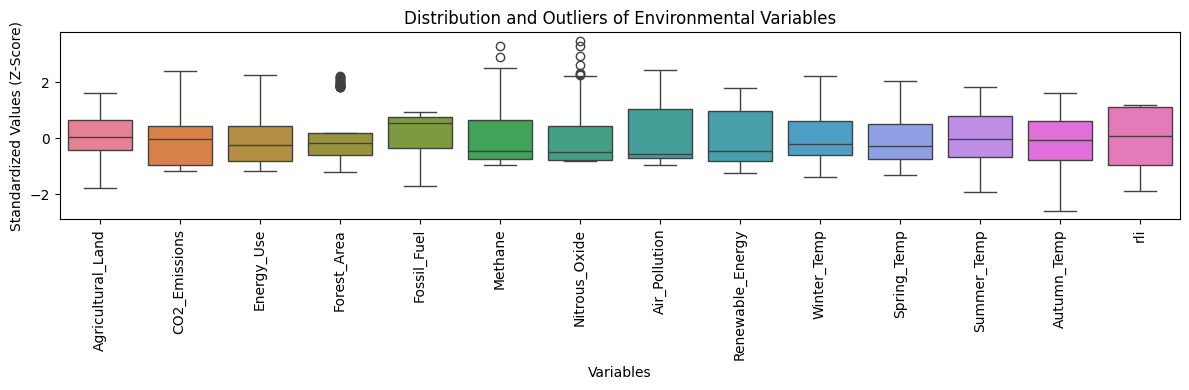

In [91]:
# DISTRIBUTION AND OUTLIER ANALYSIS
numeric_cols = panel_full.select_dtypes(include=np.number).columns
numeric_cols = [col for col in numeric_cols if col != "year"]
scaled_vis = pd.DataFrame(StandardScaler().fit_transform(panel_full[numeric_cols]),columns=numeric_cols)
plt.figure(figsize=(12,4))
sns.boxplot(data=scaled_vis)
plt.title("Distribution and Outliers of Environmental Variables")
plt.xlabel("Variables")
plt.ylabel("Standardized Values (Z-Score)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

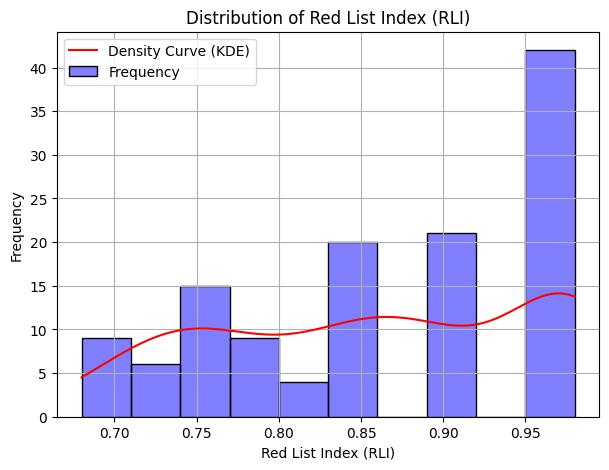

In [92]:
plt.figure(figsize=(7,5), dpi=100)
sns.histplot(panel_full["rli"],bins=10,kde=True,color="blue",label="Frequency")
# KDE line
plt.gca().lines[0].set_color("red")
plt.gca().lines[0].set_label("Density Curve (KDE)")
plt.title("Distribution of Red List Index (RLI)")
plt.xlabel("Red List Index (RLI)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

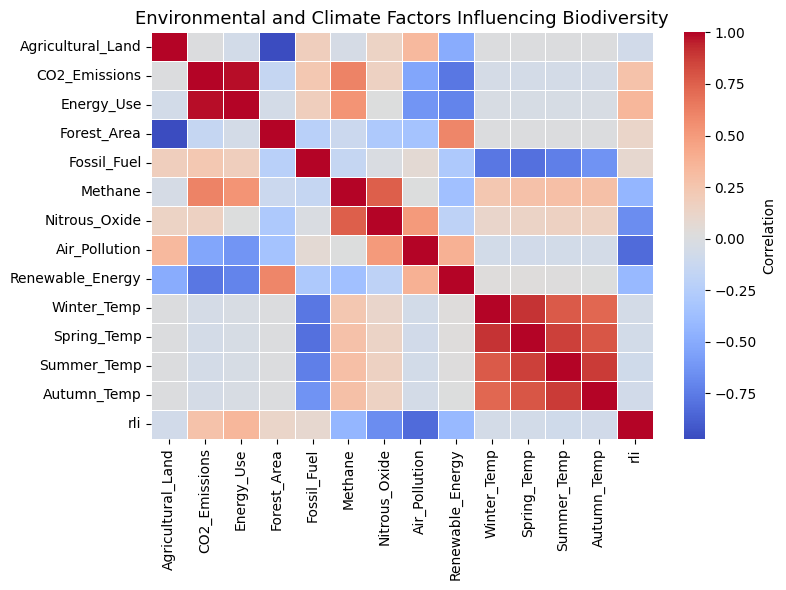

In [93]:
# CORRELATION HEATMAP
plt.figure(figsize=(8,6), dpi=100)
corr = panel_full.drop(columns=["country", "year"]).corr()
sns.heatmap(corr,cmap="coolwarm",annot=False,linewidths=0.5,cbar_kws={"label": "Correlation"})
plt.title("Environmental and Climate Factors Influencing Biodiversity",fontsize=13)
plt.tight_layout()
plt.show()

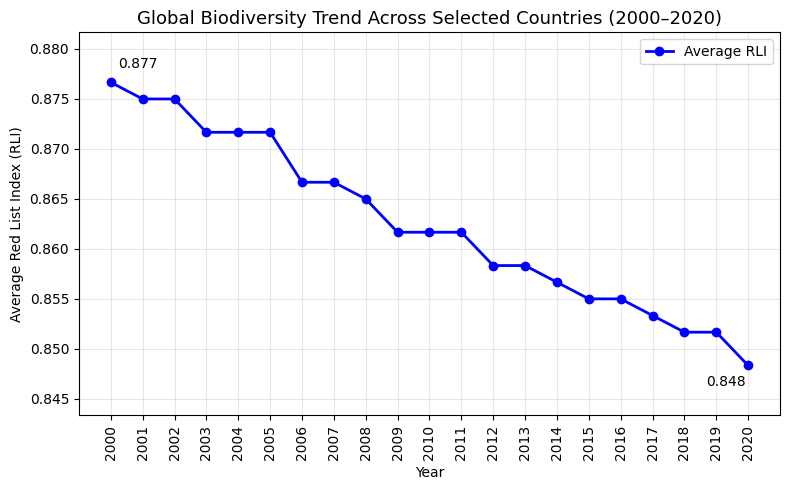

In [94]:
# GLOBAL BIODIVERSITY TREND (2000–2020)
rli_trend = panel_full.groupby("year")["rli"].mean()
plt.figure(figsize=(8,5), dpi=100)
plt.plot(rli_trend.index,rli_trend.values,marker="o",color="blue",linewidth=2,label="Average RLI")
plt.annotate(f"{rli_trend.iloc[0]:.3f}",xy=(rli_trend.index[0], rli_trend.iloc[0]),xytext=(5,10),
    textcoords="offset points")
plt.annotate(f"{rli_trend.iloc[-1]:.3f}",xy=(rli_trend.index[-1], rli_trend.iloc[-1]),xytext=(-30,-15),
    textcoords="offset points")
plt.title("Global Biodiversity Trend Across Selected Countries (2000–2020)",fontsize=13)
plt.xlabel("Year")
plt.ylabel("Average Red List Index (RLI)")
# Fix year labels
plt.xticks(ticks=rli_trend.index,labels=rli_trend.index.astype(int),rotation=90)
# Give breathing space
plt.ylim(rli_trend.min()-0.005,rli_trend.max()+0.005)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

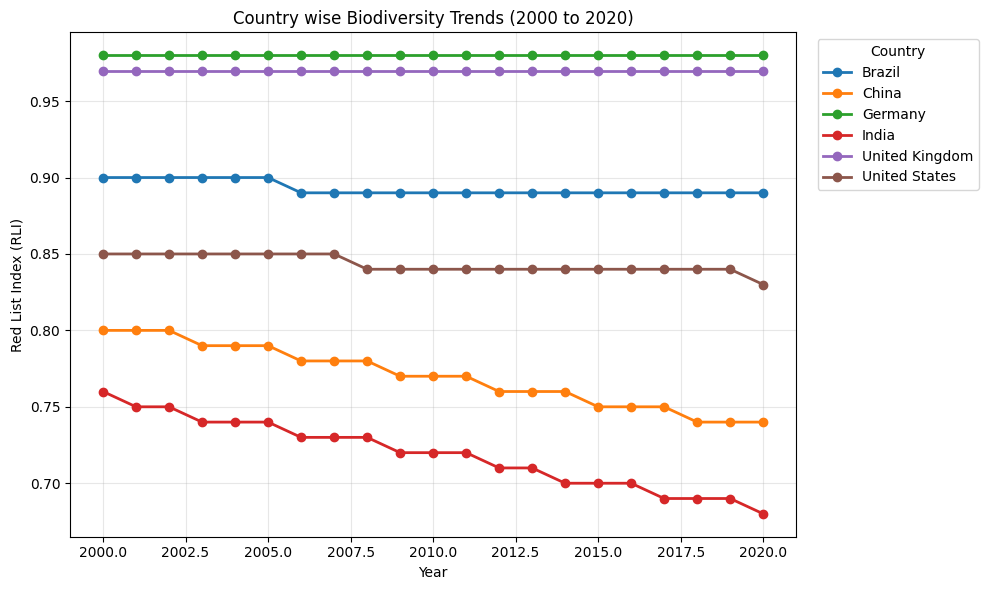

In [95]:
plt.figure(figsize=(10,6),dpi=100)
for country in panel_full["country"].unique():
    country_data = panel_full[panel_full["country"] == country]
    plt.plot(country_data["year"],country_data["rli"],marker="o",linewidth=2,label=country)
plt.title("Country wise Biodiversity Trends (2000 to 2020)")
plt.xlabel("Year")
plt.ylabel("Red List Index (RLI)")
plt.legend(title="Country",bbox_to_anchor=(1.02,1),loc="upper left")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
import plotly.express as a
Latestdata = panel_full[panel_full["year"] == 2020]
RLIglobe = a.choropleth(Latestdata,locations="country",locationmode="country names",color="rli",hover_name="country",projection="orthographic",
    color_continuous_scale="RdYlGn")
RLIglobe.update_layout(title=dict(text="Geographical Distribution of Biodiversity (RLI) Across Six Countries in 2020",x=0.5,xanchor="center",
font=dict(size=16)))
RLIglobe.show()

In [97]:
#  INITIAL VIF ANALYSIS
pressure_cols = [col for col in panel.columns if col not in ["country", "year"]]
X_pressure = panel[pressure_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pressure)
vif_data = pd.DataFrame()
vif_data["feature"] = X_pressure.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])]
vif_data = vif_data.sort_values("VIF",ascending=False).reset_index(drop=True)
print(vif_data)

                                              feature          VIF
0        Energy use (kg of oil equivalent per capita)  1144.375450
1   Carbon dioxide (CO2) emissions excluding LULUC...  1102.628676
2                        Forest area (% of land area)   701.231598
3                  Agricultural land (% of land area)   623.892924
4   Nitrous oxide (N2O) emissions from Power Indus...   325.036056
5   Methane (CH4) emissions from Power Industry (E...   241.289018
6   Terrestrial protected areas (% of total land a...    72.631519
7   Renewable energy consumption (% of total final...    71.690402
8   PM2.5 air pollution, mean annual exposure (mic...    61.988774
9                                         temp_spring    13.632028
10                                        temp_summer    13.314556
11  Terrestrial and marine protected areas (% of t...    12.584525
12                                        temp_winter     9.662488
13        Fossil fuel energy consumption (% of total)     6.15

In [98]:
# FEATURE SELECTION BASED ON VIF
drop_cols = ["Energy_Use","Agricultural_Land","Nitrous_Oxide"]
panel_filtered = panel_full.drop(columns=drop_cols, errors="ignore")
print("Shape after removing high VIF variables:")
print(panel_filtered.shape)

Shape after removing high VIF variables:
(126, 13)


In [99]:
# FINAL VIF ANALYSIS
feature_cols = [col for col in panel_filtered.columns
    if col not in ["country", "year", "rli"]]
X_vif = panel_filtered[feature_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)
vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])]
vif_data = vif_data.sort_values("VIF",ascending=False).reset_index(drop=True)
print(vif_data)

            feature       VIF
0       Spring_Temp  9.610321
1  Renewable_Energy  9.603699
2     CO2_Emissions  8.707956
3       Summer_Temp  7.229077
4       Winter_Temp  6.046282
5     Air_Pollution  5.518665
6       Forest_Area  5.517880
7       Autumn_Temp  4.720837
8       Fossil_Fuel  4.345783
9           Methane  4.294922


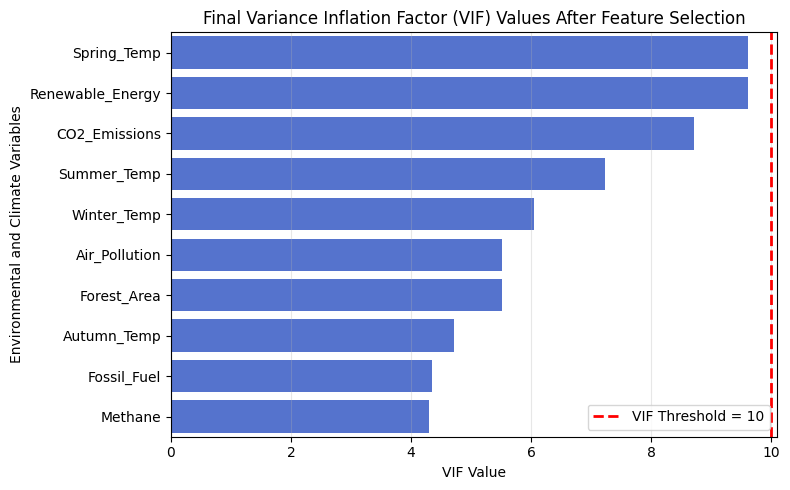

In [100]:
#FINAL VIF VALUES VISUALIZATION
plt.figure(figsize=(8,5), dpi=100)
sns.barplot(data=vif_data,x="VIF",y="feature",color="royalblue")
plt.axvline(x=10,color="red",linestyle="--",linewidth=2,label="VIF Threshold = 10")
plt.title("Final Variance Inflation Factor (VIF) Values After Feature Selection")
plt.xlabel("VIF Value")
plt.ylabel("Environmental and Climate Variables")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [101]:
# FEATURE ENGINEERING
panel_filtered["Avg_Temp"] = (panel_filtered["Winter_Temp"] +panel_filtered["Spring_Temp"] +
    panel_filtered["Summer_Temp"] +panel_filtered["Autumn_Temp"]) / 4
print(panel_filtered[["Winter_Temp","Spring_Temp","Summer_Temp","Autumn_Temp","Avg_Temp"]].head())

   Winter_Temp  Spring_Temp  Summer_Temp  Autumn_Temp  Avg_Temp
0         0.40         0.49         0.40         0.32    0.4025
1         0.39         0.54         0.53         0.58    0.5100
2         0.70         0.70         0.56         0.59    0.6375
3         0.59         0.59         0.57         0.62    0.5925
4         0.68         0.54         0.39         0.61    0.5550


In [102]:
feature_cols = [col for col in panel_filtered.columns
    if col not in ["country", "year", "rli"]]
X = panel_filtered[feature_cols]
y = panel_filtered["rli"]
print("Number of Features:", len(feature_cols))
print(feature_cols)

Number of Features: 11
['CO2_Emissions', 'Forest_Area', 'Fossil_Fuel', 'Methane', 'Air_Pollution', 'Renewable_Energy', 'Winter_Temp', 'Spring_Temp', 'Summer_Temp', 'Autumn_Temp', 'Avg_Temp']


In [103]:
from sklearn.model_selection import train_test_split
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.20,random_state=7)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.125,random_state=7)
print("Train Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Test Shape :", X_test.shape)

Train Shape : (87, 11)
Validation Shape : (13, 11)
Test Shape : (26, 11)


In [104]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (87, 11)
Validation: (13, 11)
Test: (26, 11)


In [105]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [106]:
# Generate Model Predictions
train_pred_lr = lr.predict(X_train_scaled)
val_pred_lr = lr.predict(X_val_scaled)
test_pred_lr = lr.predict(X_test_scaled)

In [107]:
# Model Performance Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
lr_train_r2 = r2_score(y_train, train_pred_lr)
lr_val_r2 = r2_score(y_val, val_pred_lr)
lr_test_r2 = r2_score(y_test, test_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test,test_pred_lr))
lr_mae = mean_absolute_error(y_test,test_pred_lr)
print("Train R² :", round(lr_train_r2,4))
print("Validation R² :", round(lr_val_r2,4))
print("Test R² :", round(lr_test_r2,4))
print("RMSE :", round(lr_rmse,4))
print("MAE :", round(lr_mae,4))

Train R² : 0.9568
Validation R² : 0.9468
Test R² : 0.937
RMSE : 0.0245
MAE : 0.0176


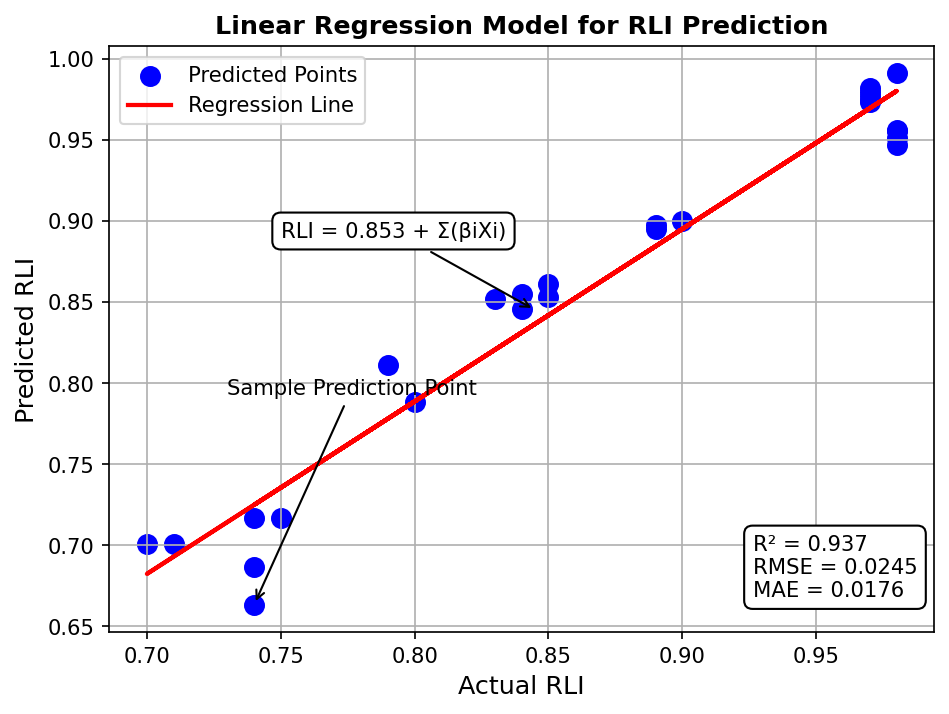

In [108]:
#Actual vs Predicted Analysis
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5),dpi=152)
plt.scatter(y_test,test_pred_lr,s=80,color="blue",label="Predicted Points")
m, b = np.polyfit(y_test, test_pred_lr, 1)
plt.plot(y_test,m*y_test + b,color="red",linewidth=2,label="Regression Line")
plt.xlabel("Actual RLI", fontsize=12)
plt.ylabel("Predicted RLI", fontsize=12)
plt.title("Linear Regression Model for RLI Prediction",fontsize=12,fontweight="bold")
plt.text(0.78,0.06,f"R² = {round(lr_test_r2,4)}\nRMSE = {round(lr_rmse,4)}\nMAE = {round(lr_mae,4)}",
    transform=plt.gca().transAxes,fontsize=10,
    bbox=dict(facecolor="white",edgecolor="black",boxstyle="round,pad=0.4"))
plt.annotate(f"RLI = {round(lr.intercept_,3)} + Σ(βiXi)",xy=(0.845, 0.845),xytext=(0.75, 0.89),arrowprops=dict(arrowstyle="->"),fontsize=10,
    bbox=dict(facecolor="white",edgecolor="black",boxstyle="round,pad=0.4"))
idx = np.argmin(test_pred_lr)
plt.annotate("Sample Prediction Point",
    xy=(y_test.iloc[idx], test_pred_lr[idx]),
    xytext=(y_test.iloc[idx]-0.01,
            test_pred_lr[idx]+0.13),arrowprops=dict(arrowstyle="->"),fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

In [109]:
print("Intercept (β₀):", lr.intercept_)
print("Coefficients (β values):")
for feature, coef in zip(X.columns, lr.coef_):
    print(feature, ":", round(coef, 6))

Intercept (β₀): 0.8528735632183908
Coefficients (β values):
CO2_Emissions : -0.007627
Forest_Area : 0.024037
Fossil_Fuel : -0.007839
Methane : -0.059366
Air_Pollution : -0.051628
Renewable_Energy : -0.067163
Winter_Temp : -0.002542
Spring_Temp : -0.000119
Summer_Temp : -0.002581
Autumn_Temp : 0.005765
Avg_Temp : -6e-05


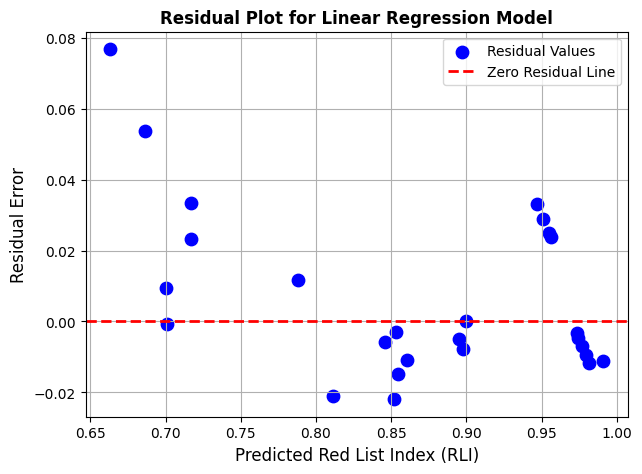

In [110]:
# Residual Plot for Linear Regression Model
residuals = y_test - test_pred_lr
plt.figure(figsize=(7,5))
plt.scatter(test_pred_lr,residuals,s=80,color="blue",label="Residual Values")
plt.axhline(y=0,color="red",linestyle="--",linewidth=2,label="Zero Residual Line")
plt.xlabel("Predicted Red List Index (RLI)",fontsize=12)
plt.ylabel("Residual Error",fontsize=12)
plt.title("Residual Plot for Linear Regression Model",fontsize=12,fontweight="bold")
idx = 10
plt.legend()
plt.grid(True)
plt.show()

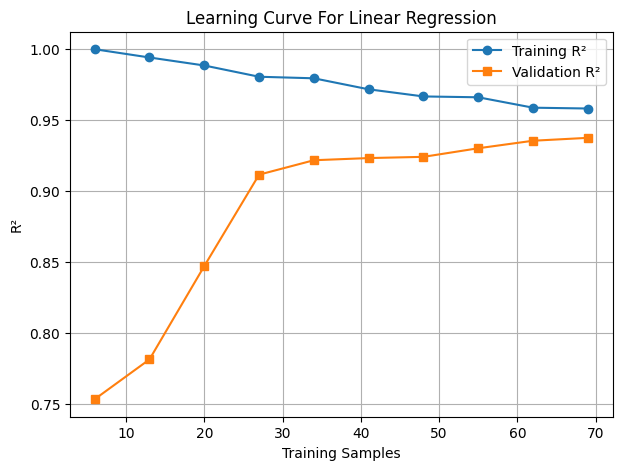

In [111]:
# Learning Curve Analysis
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
train_sizes, train_scores, val_scores = learning_curve(LinearRegression(),X_train_scaled,y_train,cv=5,scoring='r2',
                                                       train_sizes=np.linspace(0.1,1.0,10))
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes,train_mean,marker='o',label='Training R²')
plt.plot(train_sizes,val_mean,marker='s',label='Validation R²')
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Learning Curve For Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

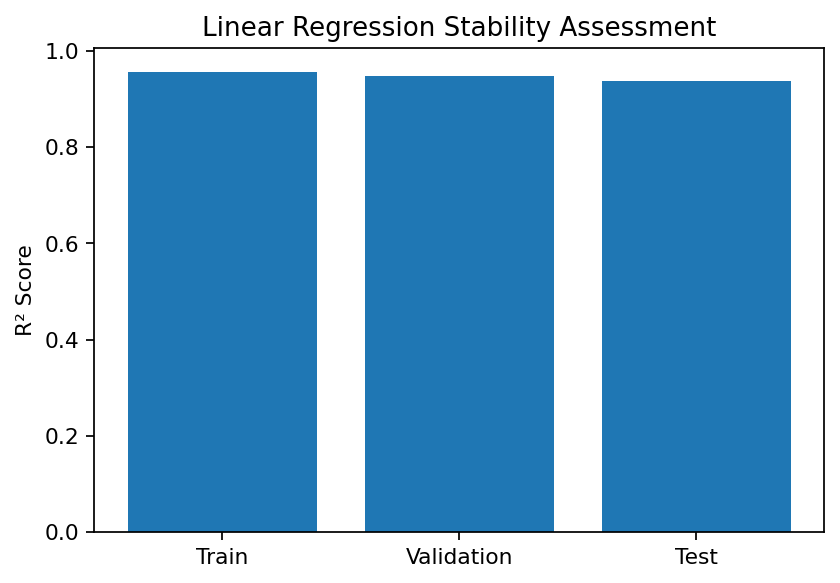

In [112]:
# Model Stability Assessment
plt.figure(figsize=(6,4),dpi=157)
plt.bar(["Train","Validation","Test"],[lr_train_r2, lr_val_r2, lr_test_r2])
plt.ylabel("R² Score")
plt.title("Linear Regression Stability Assessment")
plt.show()


In [113]:
# 13.1 Random Forest Model Training
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=30,max_depth=2,min_samples_split=15,min_samples_leaf=8)
rf.fit(X_train_scaled,y_train)


RandomForestRegressor(max_depth=2, min_samples_leaf=8, min_samples_split=15,
                      n_estimators=30)

In [114]:
#  Generate Random Forest Predictions
train_pred_rf = rf.predict(X_train_scaled)
val_pred_rf = rf.predict(X_val_scaled)
test_pred_rf = rf.predict(X_test_scaled)

In [115]:
#  Random Forest Performance Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
rf_train_r2 = r2_score(y_train,train_pred_rf)
rf_val_r2 = r2_score(y_val,val_pred_rf)
rf_test_r2 = r2_score(y_test,test_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test,test_pred_rf))
rf_mae = mean_absolute_error(y_test,test_pred_rf)
print("Train R² :", round(rf_train_r2,4))
print("Validation R² :", round(rf_val_r2,4))
print("Test R² :", round(rf_test_r2,4))
print("RMSE :", round(rf_rmse,4))
print("MAE :", round(rf_mae,4))

Train R² : 0.9652
Validation R² : 0.9621
Test R² : 0.9586
RMSE : 0.0199
MAE : 0.0159


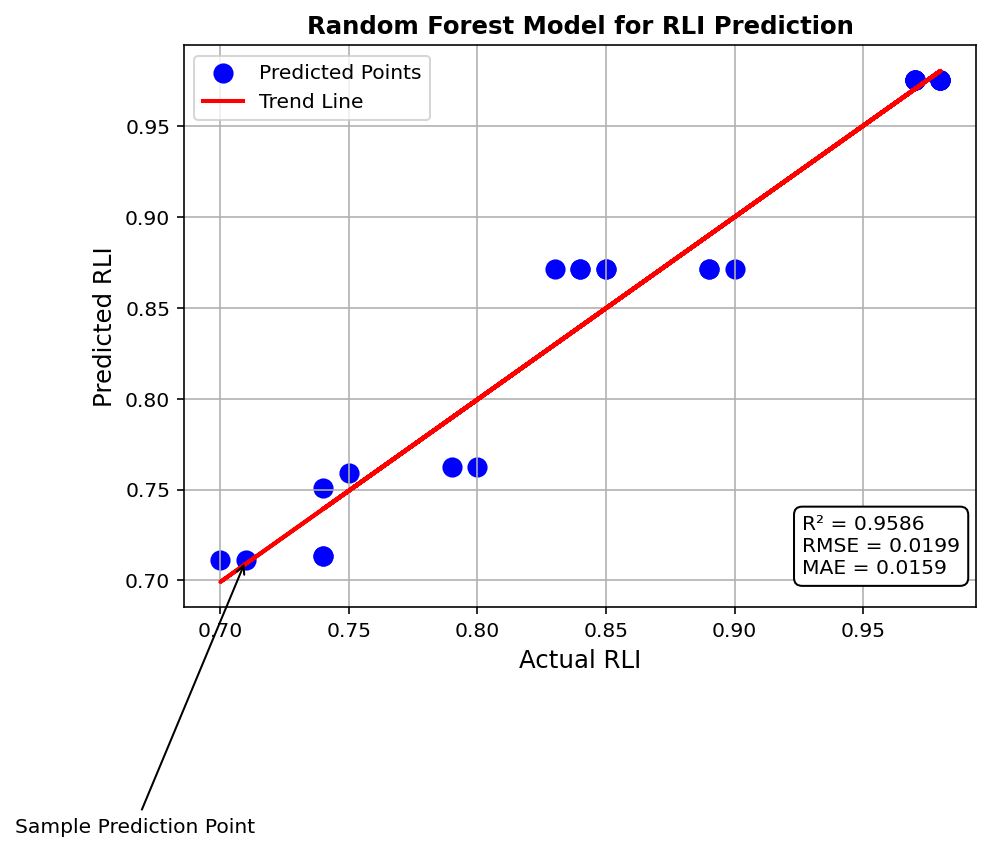

In [116]:
#  Actual vs Predicted Analysis
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5),dpi=146)
plt.scatter(y_test,test_pred_rf,s=80,color="blue",label="Predicted Points")
m, b = np.polyfit(y_test, test_pred_rf, 1)
plt.plot(y_test,m*y_test + b,color="red",linewidth=2,label="Trend Line")
plt.xlabel("Actual RLI", fontsize=12)
plt.ylabel("Predicted RLI", fontsize=12)
plt.title("Random Forest Model for RLI Prediction",fontsize=12,fontweight="bold")
plt.text(0.78,0.06,f"R² = {round(rf_test_r2,4)}\nRMSE = {round(rf_rmse,4)}\nMAE = {round(rf_mae,4)}",
    transform=plt.gca().transAxes,fontsize=10,
    bbox=dict(facecolor="white",edgecolor="black",boxstyle="round,pad=0.4"))
idx = 2
plt.annotate("Sample Prediction Point",xy=(y_test.iloc[idx], test_pred_rf[idx]),
    xytext=(y_test.iloc[idx]-0.09, test_pred_rf[idx]-0.15),
    arrowprops=dict(facecolor="black",arrowstyle="->"),fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

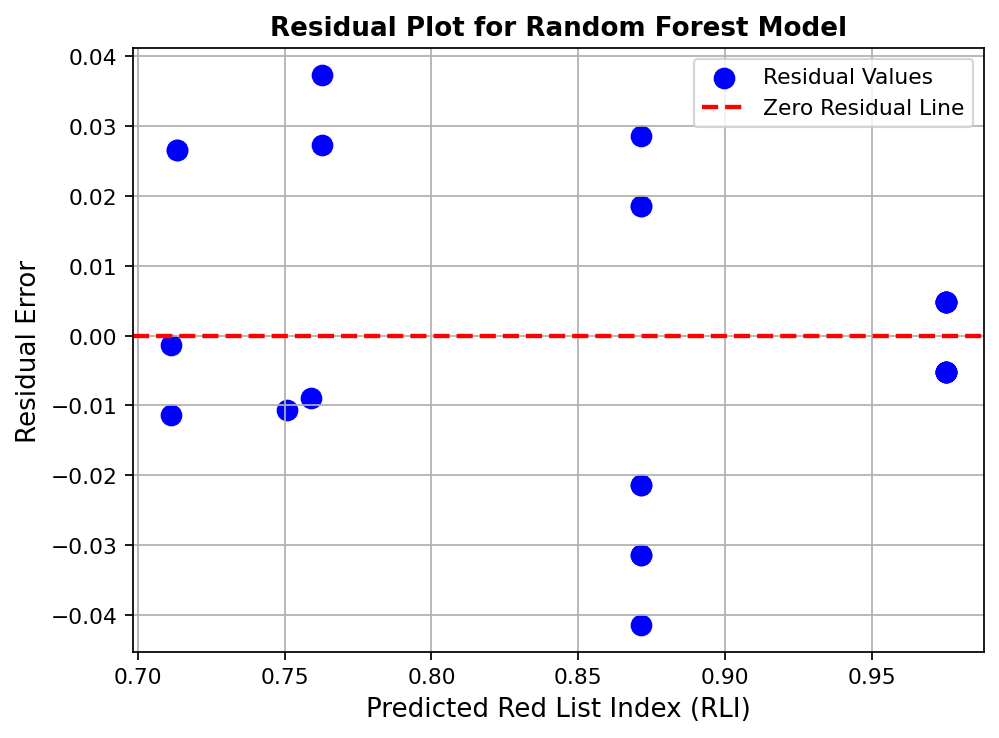

In [117]:
# 13.5 Residual Error Analysis
residuals_rf = y_test - test_pred_rf
plt.figure(figsize=(7,5),dpi=157)
plt.scatter(test_pred_rf,residuals_rf,s=80,color="blue",label="Residual Values")
plt.axhline(y=0,color="red",linestyle="--",linewidth=2,label="Zero Residual Line")
plt.xlabel("Predicted Red List Index (RLI)",fontsize=12)
plt.ylabel("Residual Error",fontsize=12)
plt.title("Residual Plot for Random Forest Model",fontsize=12,fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

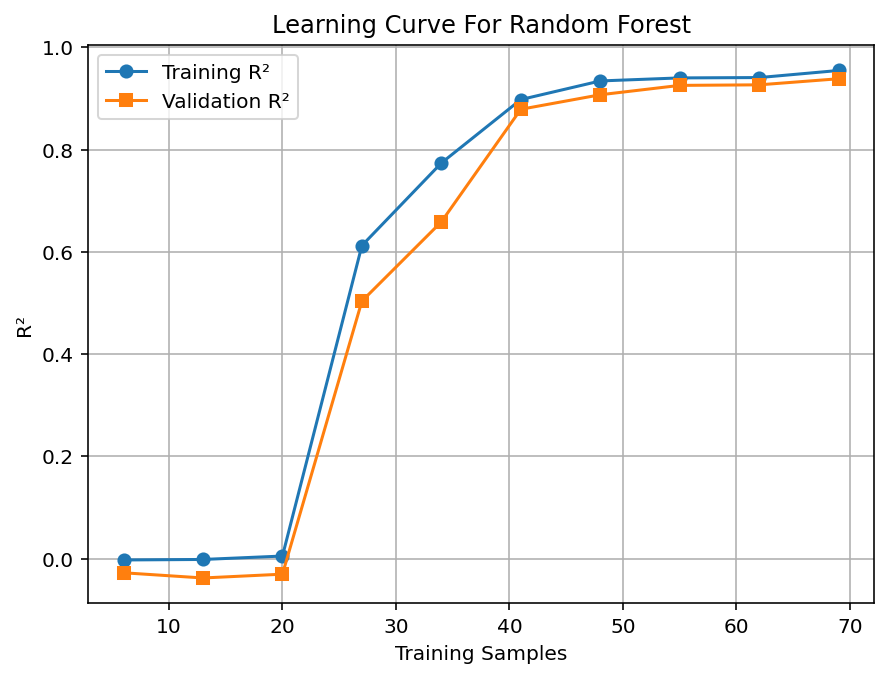

In [118]:
# Learning Curve Analysis
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(rf,X_train_scaled,y_train,cv=5,scoring='r2',train_sizes=np.linspace(0.1,1.0,10))
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(7,5),dpi=145)
plt.plot(train_sizes,train_mean,marker='o',label='Training R²')
plt.plot(train_sizes,val_mean,marker='s',label='Validation R²')
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Learning Curve For Random Forest")
plt.legend()
plt.grid(True)
plt.show()

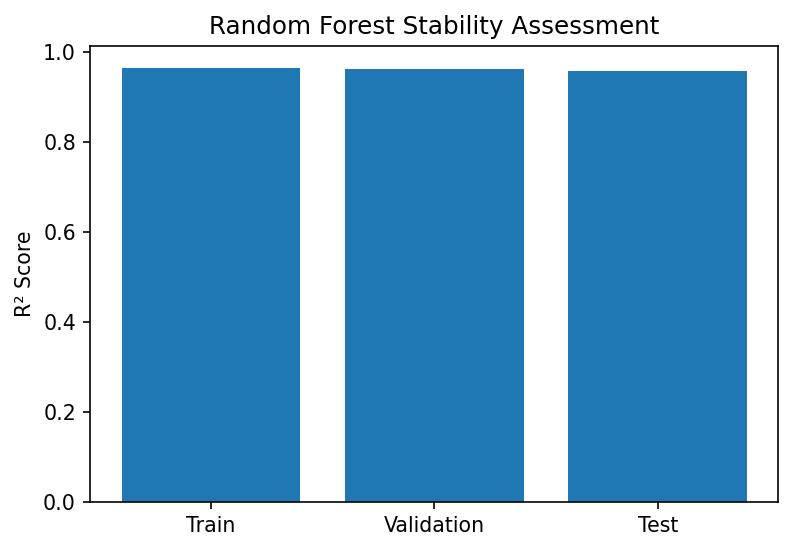

In [119]:
#  Model Stability Assessment
plt.figure(figsize=(6,4),dpi=148)
plt.bar(["Train","Validation","Test"],[rf_train_r2, rf_val_r2, rf_test_r2])
plt.ylabel("R² Score")
plt.title("Random Forest Stability Assessment")
plt.show()

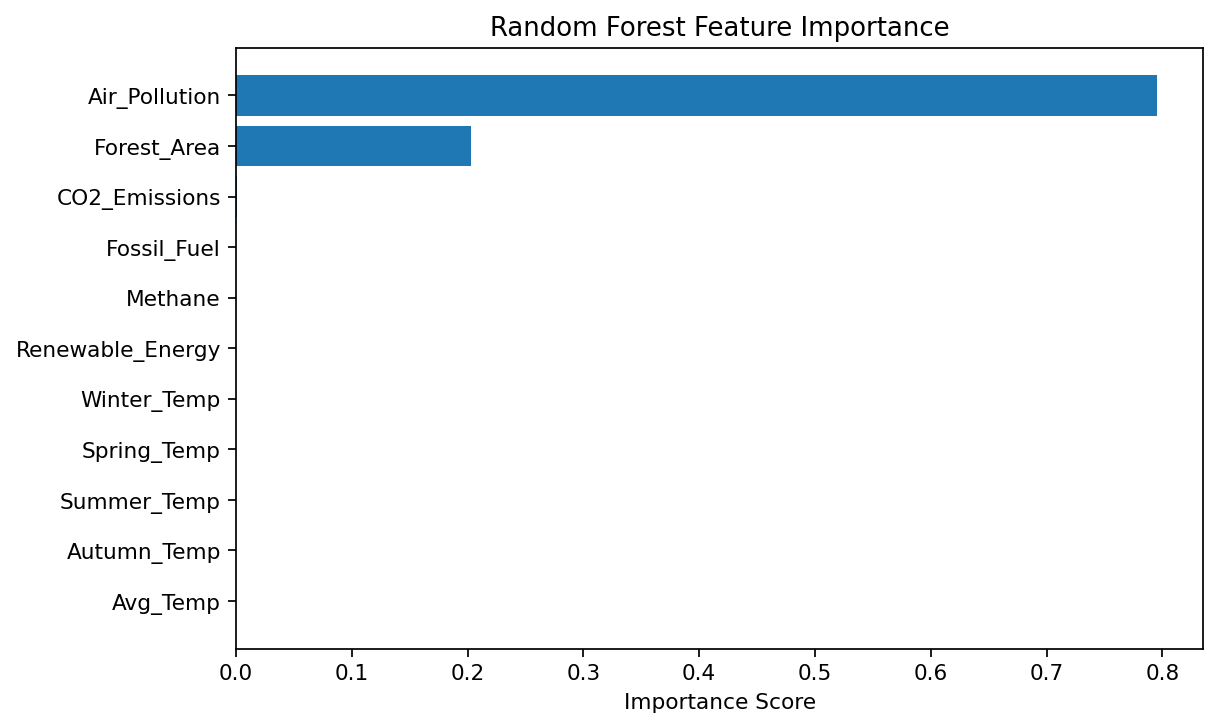

,Feature,Importance
4,Air_Pollution,0.795665
1,Forest_Area,0.203162
0,CO2_Emissions,0.001173
2,Fossil_Fuel,0.000000
3,Methane,0.000000
5,Renewable_Energy,0.000000
6,Winter_Temp,0.000000
7,Spring_Temp,0.000000
8,Summer_Temp,0.000000
9,Autumn_Temp,0.000000


In [120]:
# Feature Importance Analysis
importance_df = pd.DataFrame({"Feature": feature_cols,"Importance": rf.feature_importances_})
importance_df = importance_df.sort_values(by="Importance",ascending=False)
plt.figure(figsize=(8,5),dpi=156)
plt.barh(importance_df["Feature"],importance_df["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()
importance_df

In [121]:
# Hyperparameter Optimisation
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [20, 30, 50],'max_depth': [2, 3, 4],
    'min_samples_split': [10, 15, 20],'min_samples_leaf': [4, 6, 8]}
grid_rf = GridSearchCV(estimator=RandomForestRegressor(),param_grid=param_grid,
    cv=5,scoring='r2',n_jobs=-1)
grid_rf.fit(X_train_scaled,y_train)
print("Best Parameters:")
print(grid_rf.best_params_)
print("\nBest Cross Validation R²:")
print(round(grid_rf.best_score_,4))

Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 30}

Best Cross Validation R²:
0.9902


In [122]:
# Optimised Random Forest Model
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train_scaled,y_train)


RandomForestRegressor(max_depth=3, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=30)

In [123]:
# Optimised Random Forest Evaluation
train_pred_rf_opt = best_rf.predict(X_train_scaled)
val_pred_rf_opt = best_rf.predict(X_val_scaled)
test_pred_rf_opt = best_rf.predict(X_test_scaled)
rf_opt_train_r2 = r2_score(y_train,train_pred_rf_opt)
rf_opt_val_r2 = r2_score(y_val,val_pred_rf_opt)
rf_opt_test_r2 = r2_score(y_test,test_pred_rf_opt)
rf_opt_rmse = np.sqrt(mean_squared_error(y_test,test_pred_rf_opt))
rf_opt_mae = mean_absolute_error(y_test,test_pred_rf_opt)
print("Train R² :", round(rf_opt_train_r2,4))
print("Validation R² :", round(rf_opt_val_r2,4))
print("Test R² :", round(rf_opt_test_r2,4))
print("RMSE :", round(rf_opt_rmse,4))
print("MAE :", round(rf_opt_mae,4))

Train R² : 0.9966
Validation R² : 0.9939
Test R² : 0.9884
RMSE : 0.0105
MAE : 0.0059


In [124]:
# 13.12 Before vs After Tuning Comparison
comparison = pd.DataFrame({"Metric": ["Test R²","RMSE","MAE"],
    "Baseline RF": [rf_test_r2,rf_rmse,rf_mae],
    "Optimised RF": [rf_opt_test_r2,rf_opt_rmse,rf_opt_mae]})
comparison

,Metric,Baseline RF,Optimised RF
0,Test R²,0.958554,0.988415
1,RMSE,0.019855,0.010497
2,MAE,0.015885,0.005915


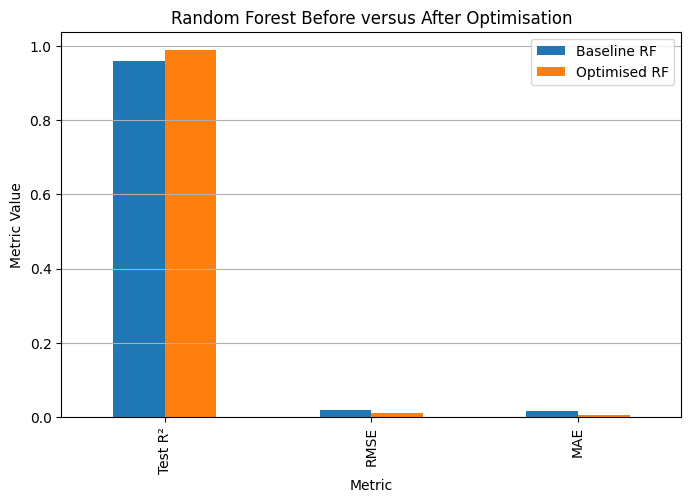

In [125]:
# RF Optimisation Comparison
comparison_plot = comparison.set_index("Metric")
comparison_plot.plot(kind="bar",figsize=(8,5))
plt.title("Random Forest Before versus After Optimisation")
plt.ylabel("Metric Value")
plt.grid(axis='y')
plt.show()

In [126]:
#  Gradient Boosting Model Training
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=50,learning_rate=0.04,max_depth=2,)
gb.fit(X_train_scaled,y_train)
print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [127]:
#  Generate Model Predictions
train_pred_gb = gb.predict(X_train_scaled)
val_pred_gb = gb.predict(X_val_scaled)
test_pred_gb = gb.predict(X_test_scaled)

In [128]:
# Model Performance Evaluation
gb_train_r2 = r2_score(y_train,train_pred_gb)
gb_val_r2 = r2_score(y_val,val_pred_gb)
gb_test_r2 = r2_score(y_test,test_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test,test_pred_gb))
gb_mae = mean_absolute_error(y_test,test_pred_gb)
print("Train R² :", round(gb_train_r2,4))
print("Validation R² :", round(gb_val_r2,4))
print("Test R² :", round(gb_test_r2,4))
print("RMSE :", round(gb_rmse,4))
print("MAE :", round(gb_mae,4))

Train R² : 0.9728
Validation R² : 0.9608
Test R² : 0.9742
RMSE : 0.0157
MAE : 0.0137


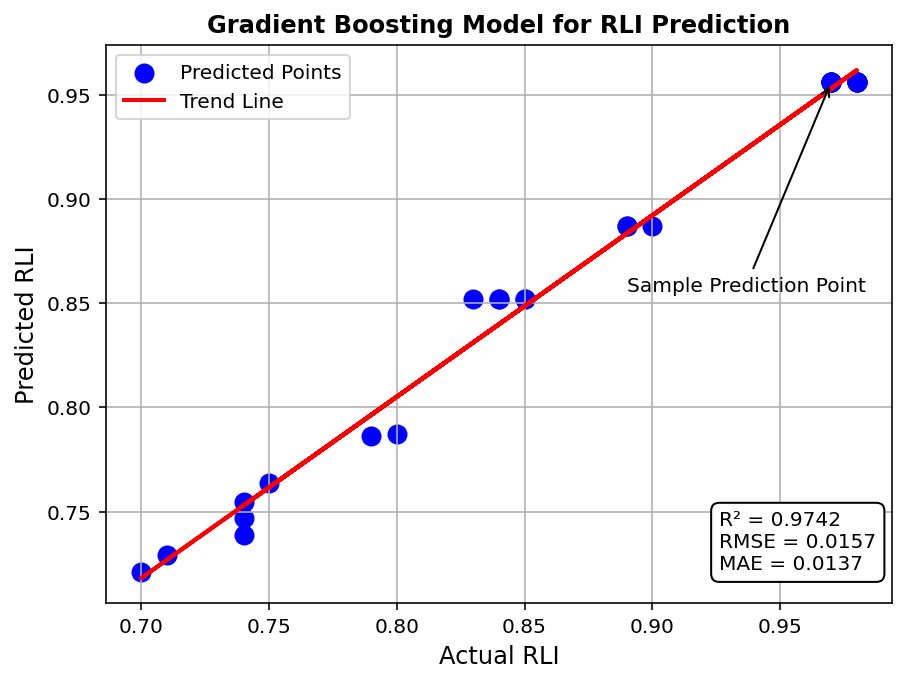

In [129]:
# Actual versus Predicted Analysis
plt.figure(figsize=(7,5),dpi=145)
plt.scatter(y_test,test_pred_gb,s=80,color="blue",label="Predicted Points")
m, b = np.polyfit(y_test, test_pred_gb, 1)
plt.plot(y_test,m*y_test + b,color="red",linewidth=2,label="Trend Line")
plt.xlabel("Actual RLI", fontsize=12)
plt.ylabel("Predicted RLI", fontsize=12)
plt.title("Gradient Boosting Model for RLI Prediction",fontsize=12,fontweight="bold")
plt.text(0.78,0.06,f"R² = {round(gb_test_r2,4)}\nRMSE = {round(gb_rmse,4)}\nMAE = {round(gb_mae,4)}",transform=plt.gca().transAxes,
    fontsize=10,bbox=dict(facecolor="white",edgecolor="black",boxstyle="round,pad=0.4"))
idx = 10
plt.annotate("Sample Prediction Point",xy=(y_test.iloc[idx], test_pred_gb[idx]),
    xytext=(y_test.iloc[idx]-0.08, test_pred_gb[idx]-0.10),
    arrowprops=dict(facecolor="black",arrowstyle="->"),fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

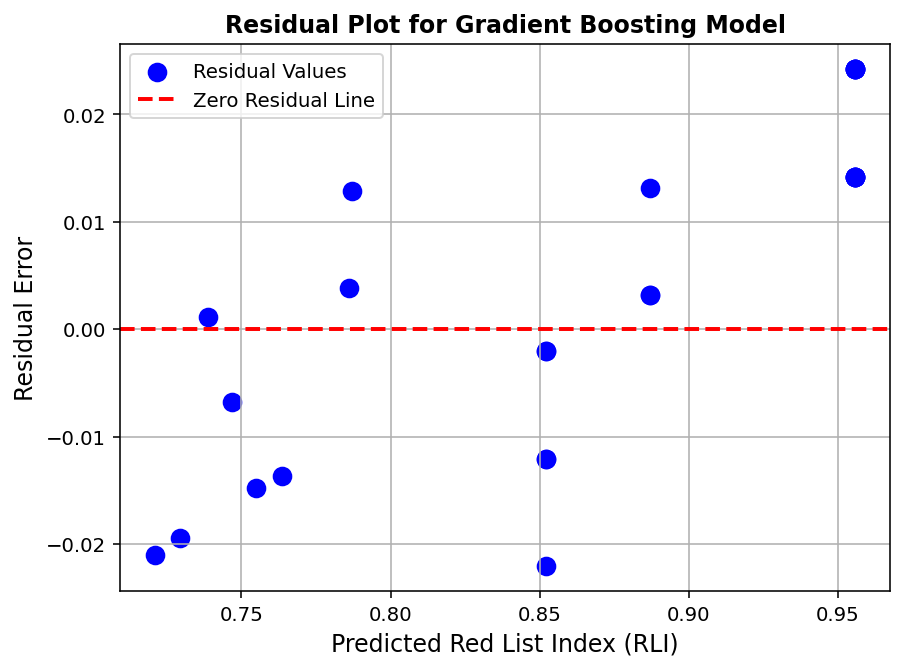

In [130]:
#  Residual Error Analysis
residuals_gb = y_test - test_pred_gb
plt.figure(figsize=(7,5),dpi=142)
plt.scatter(test_pred_gb,residuals_gb,s=80,color="blue",label="Residual Values")
plt.axhline(y=0,color="red",linestyle="--",linewidth=2,label="Zero Residual Line")
plt.xlabel("Predicted Red List Index (RLI)",fontsize=12)
plt.ylabel("Residual Error",fontsize=12)
plt.title("Residual Plot for Gradient Boosting Model",fontsize=12,fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

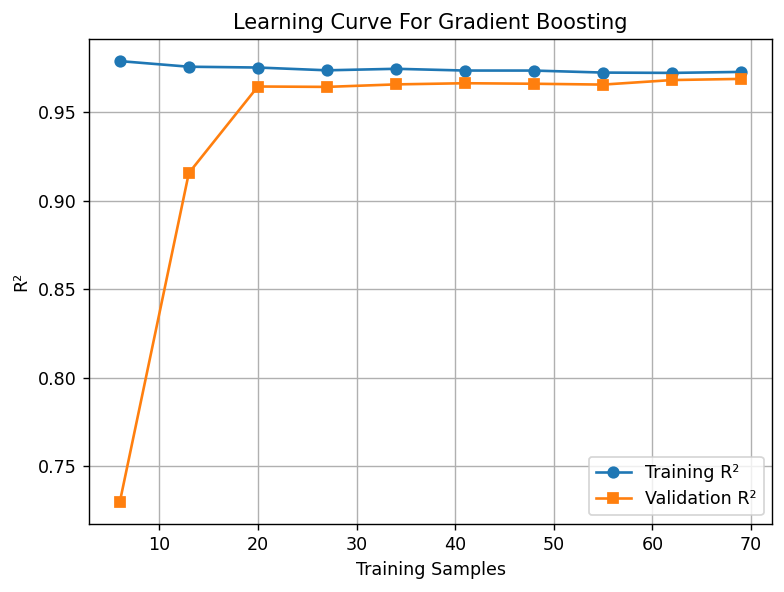

In [131]:
#  Learning Curve Analysis
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(gb,X_train_scaled,y_train,
    cv=5,scoring='r2',train_sizes=np.linspace(0.1,1.0,10))
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
plt.figure(figsize=(7,5),dpi=126)
plt.plot(train_sizes,train_mean,marker='o',label='Training R²')
plt.plot(train_sizes,val_mean,marker='s',label='Validation R²')
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Learning Curve For Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

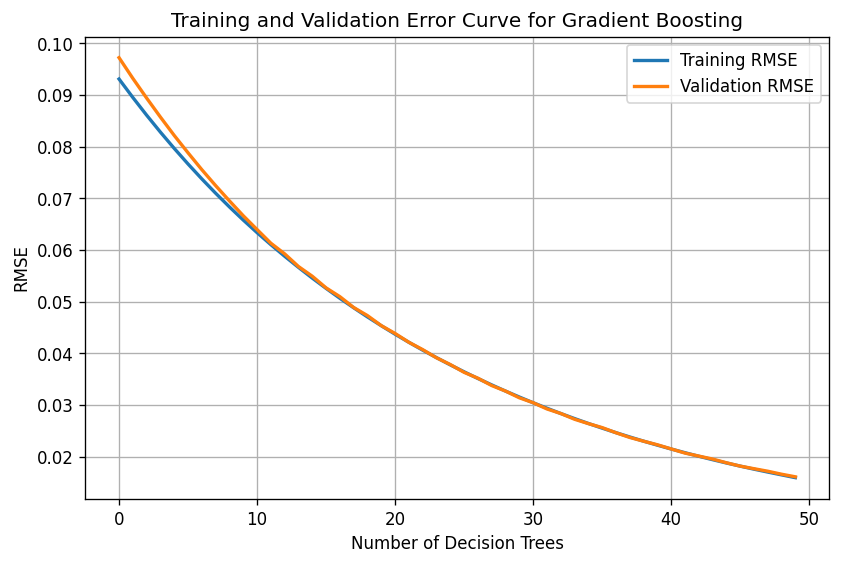

In [132]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
train_rmse = []
val_rmse = []
for pred_train, pred_val in zip(
    gb.staged_predict(X_train_scaled),
    gb.staged_predict(X_val_scaled)
):

    train_rmse.append(np.sqrt(mean_squared_error(y_train, pred_train)))
    val_rmse.append(np.sqrt(mean_squared_error(y_val, pred_val)))
plt.figure(figsize=(8,5), dpi=120)
plt.plot(train_rmse, label="Training RMSE", linewidth=2)
plt.plot(val_rmse, label="Validation RMSE", linewidth=2)
plt.xlabel("Number of Decision Trees")
plt.ylabel("RMSE")
plt.title("Training and Validation Error Curve for Gradient Boosting")
plt.legend()
plt.grid(True)
plt.show()

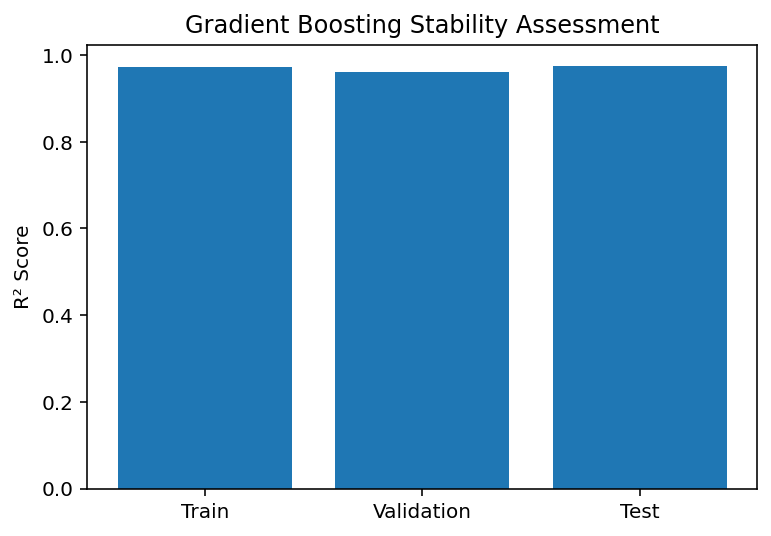

In [133]:
# Model Stability Assessment
plt.figure(figsize=(6,4),dpi=144)
plt.bar(["Train","Validation","Test"],[gb_train_r2, gb_val_r2, gb_test_r2])
plt.ylabel("R² Score")
plt.title("Gradient Boosting Stability Assessment")
plt.show()

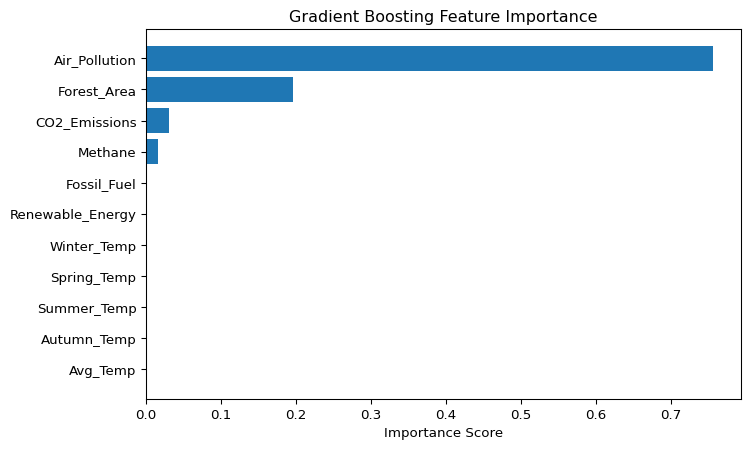

,Feature,Importance
4,Air_Pollution,0.755279
1,Forest_Area,0.195812
0,CO2_Emissions,0.031256
3,Methane,0.016105
2,Fossil_Fuel,0.001547
5,Renewable_Energy,0.000000
6,Winter_Temp,0.000000
7,Spring_Temp,0.000000
8,Summer_Temp,0.000000
9,Autumn_Temp,0.000000


In [134]:
# 14.8 Feature Importance Analysis
importance_df_gb = pd.DataFrame({"Feature": feature_cols,"Importance": gb.feature_importances_})
importance_df_gb = importance_df_gb.sort_values(by="Importance",ascending=False)
plt.figure(figsize=(8,5),dpi=96)
plt.barh(importance_df_gb["Feature"],importance_df_gb["Importance"])
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()
importance_df_gb

In [135]:
# Hyperparameter Optimisation
from sklearn.model_selection import GridSearchCV
param_grid_gb = {'n_estimators': [30, 50, 100],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4]}
grid_gb = GridSearchCV(GradientBoostingRegressor(),param_grid=param_grid_gb,
    cv=5,scoring='r2',n_jobs=-1)
grid_gb.fit(X_train_scaled,y_train)
print("Best Parameters:")
print(grid_gb.best_params_)
print("Best CV Score:")
print(round(grid_gb.best_score_,4))

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50}
Best CV Score:
0.9985


In [136]:
#  Optimised Gradient Boosting
best_gb = grid_gb.best_estimator_
best_gb.fit(X_train_scaled,y_train)


GradientBoostingRegressor(max_depth=4, n_estimators=50)

In [137]:
# Optimised GB Evaluation
train_pred_gb_opt = best_gb.predict(X_train_scaled)
val_pred_gb_opt = best_gb.predict(X_val_scaled)
test_pred_gb_opt = best_gb.predict(X_test_scaled)
gb_opt_train_r2 = r2_score(y_train,train_pred_gb_opt)
gb_opt_val_r2 = r2_score(y_val,val_pred_gb_opt)
gb_opt_test_r2 = r2_score(y_test,test_pred_gb_opt)
gb_opt_rmse = np.sqrt(mean_squared_error(y_test,test_pred_gb_opt))
gb_opt_mae = mean_absolute_error(y_test,test_pred_gb_opt)
print("Train R² :", round(gb_opt_train_r2,4))
print("Validation R² :", round(gb_opt_val_r2,4))
print("Test R² :", round(gb_opt_test_r2,4))
print("RMSE :", round(gb_opt_rmse,4))
print("MAE :", round(gb_opt_mae,4))

Train R² : 1.0
Validation R² : 0.9977
Test R² : 0.9903
RMSE : 0.0096
MAE : 0.0045


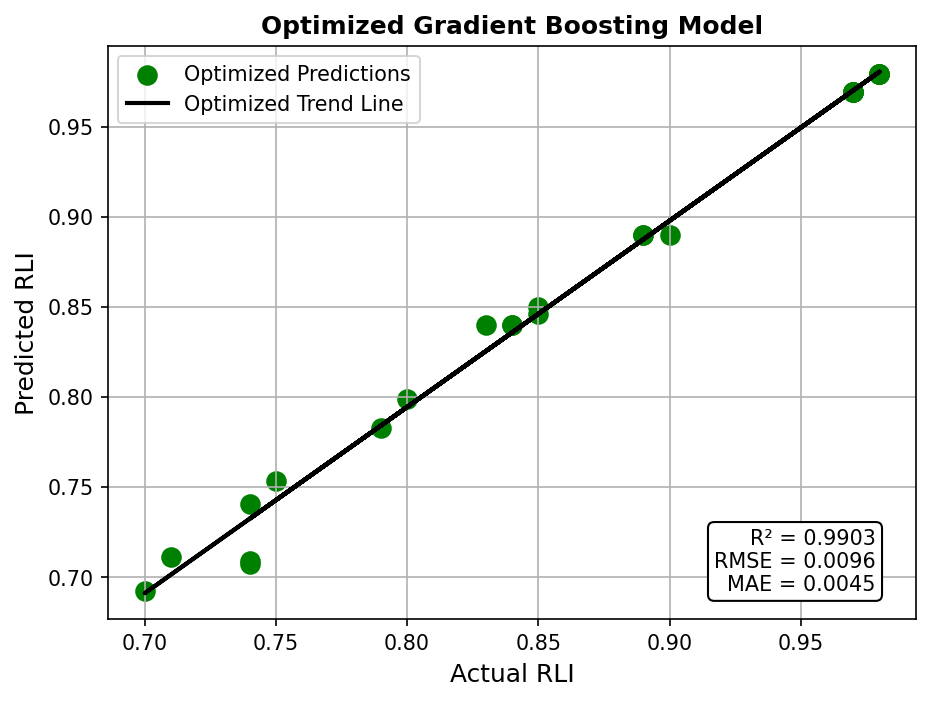

In [138]:
plt.figure(figsize=(7,5),dpi=149)
plt.scatter(y_test,test_pred_gb_opt,s=80,color="green",label="Optimized Predictions")
# Trend Line
m, b = np.polyfit(y_test, test_pred_gb_opt, 1)
plt.plot(y_test,m*y_test + b,color="black",linewidth=2,label="Optimized Trend Line")
plt.xlabel("Actual RLI", fontsize=12)
plt.ylabel("Predicted RLI", fontsize=12)
plt.title("Optimized Gradient Boosting Model",fontsize=12,fontweight="bold")
# Metrics Box
plt.text(0.95,0.05,
    f"R² = {round(gb_opt_test_r2,4)}\nRMSE = {round(gb_opt_rmse,4)}\nMAE = {round(gb_opt_mae,4)}",
    transform=plt.gca().transAxes,ha="right",
    bbox=dict(facecolor="white",edgecolor="black",boxstyle="round"))
plt.legend()
plt.grid(True)
plt.show()

In [139]:
#  Before and After Tuning  compare
comparison_gb = pd.DataFrame({"Metric": ["Test R²","RMSE","MAE"],
    "Baseline GB": [gb_test_r2,gb_rmse,gb_mae],
    "Optimised GB": [gb_opt_test_r2,gb_opt_rmse,gb_opt_mae]})
comparison_gb

,Metric,Baseline GB,Optimised GB
0,Test R²,0.974247,0.990347
1,RMSE,0.015651,0.009582
2,MAE,0.013666,0.004454


In [140]:
#  ANN Model Training
from sklearn.neural_network import MLPRegressor
ann = MLPRegressor(hidden_layer_sizes=(8),activation='relu',solver='adam',
    alpha=0.01,learning_rate_init=0.05,max_iter=450,random_state=7)
ann.fit(X_train_scaled,y_train)


MLPRegressor(alpha=0.01, hidden_layer_sizes=8, learning_rate_init=0.05,
             max_iter=450, random_state=7)

In [141]:
#  ANN Predictions
train_pred_ann = ann.predict(X_train_scaled)
val_pred_ann = ann.predict(X_val_scaled)
test_pred_ann = ann.predict(X_test_scaled)

In [142]:
# ANN Performance Evaluation
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
ann_train_r2 = r2_score(y_train,train_pred_ann)
ann_val_r2 = r2_score(y_val,val_pred_ann)
ann_test_r2 = r2_score(y_test,test_pred_ann)
ann_rmse = np.sqrt(mean_squared_error(y_test,test_pred_ann))
ann_mae = mean_absolute_error(y_test,test_pred_ann)
print("Train R² :", round(ann_train_r2,4))
print("Validation R² :", round(ann_val_r2,4))
print("Test R² :", round(ann_test_r2,4))
print("RMSE :", round(ann_rmse,4))
print("MAE :", round(ann_mae,4))

Train R² : 0.8864
Validation R² : 0.7338
Test R² : 0.8717
RMSE : 0.0349
MAE : 0.0281


In [143]:
import tensorflow as tf
print(tf.__version__)
print(X_train_scaled.shape)
print(X_test_scaled.shape)

2.20.0
(87, 11)
(26, 11)


In [144]:
print(X.columns)
print(len(X.columns))

Index(['CO2_Emissions', 'Forest_Area', 'Fossil_Fuel', 'Methane',
       'Air_Pollution', 'Renewable_Energy', 'Winter_Temp', 'Spring_Temp',
       'Summer_Temp', 'Autumn_Temp', 'Avg_Temp'],
      dtype='object')
11


In [145]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
ann_model = Sequential([Dense(4, activation='relu', input_shape=(11,)),Dense(1)])
ann_model.compile(optimizer=Adam(learning_rate=0.001),loss='mse')
history = ann_model.fit(X_train_scaled,y_train,validation_data=(X_val_scaled, y_val),epochs=200,batch_size=8,verbose=1)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.3725 - val_loss: 1.2462
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2100 - val_loss: 1.0696
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0754 - val_loss: 0.9238
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9634 - val_loss: 0.7860
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8577 - val_loss: 0.6898
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7773 - val_loss: 0.6017
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7072 - val_loss: 0.5310
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6477 - val_loss: 0.4704
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5932 - val_loss: 0.4176
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5471 - val_loss: 0.3692
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5065 - val_loss: 0.3284
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4667 - val_l

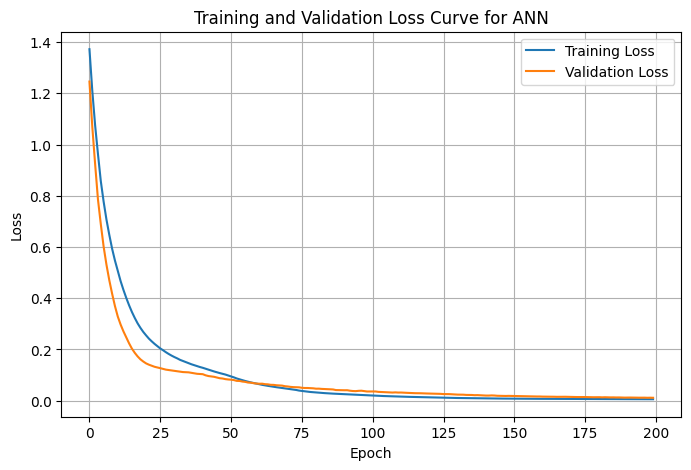

In [146]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve for ANN')
plt.legend()
plt.grid(True)
plt.show()

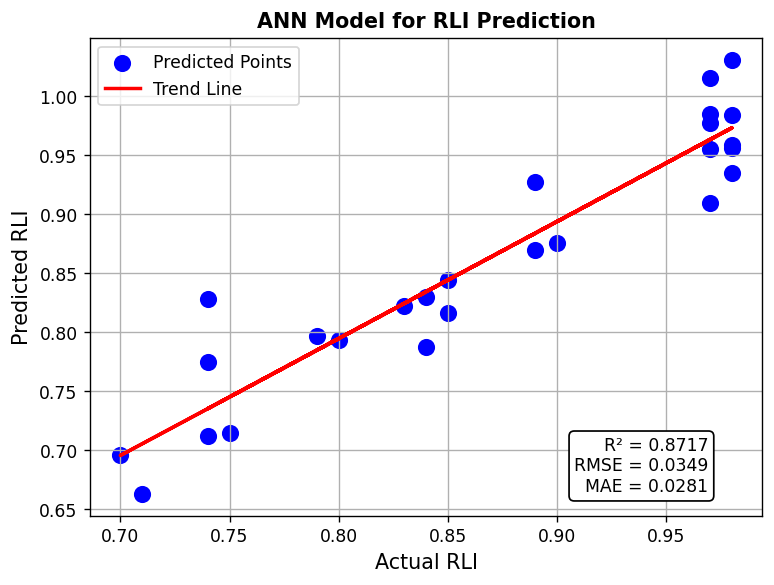

In [147]:
# ANN Actual vs Predicted
plt.figure(figsize=(7,5),dpi=124)
plt.scatter(y_test,test_pred_ann,s=80,color="blue",label="Predicted Points")
# Trend Line
m, b = np.polyfit(y_test, test_pred_ann, 1)
plt.plot(y_test,m * y_test + b,color="red",linewidth=2,label="Trend Line")
plt.xlabel("Actual RLI", fontsize=12)
plt.ylabel("Predicted RLI", fontsize=12)
plt.title("ANN Model for RLI Prediction",fontsize=12,fontweight="bold")
# Metrics Box
plt.text(0.92,0.05,
    f"R² = {round(ann_test_r2,4)}\nRMSE = {round(ann_rmse,4)}\nMAE = {round(ann_mae,4)}",
    transform=plt.gca().transAxes,ha="right",
    bbox=dict(facecolor="white",edgecolor="black",boxstyle="round"))
plt.legend()
plt.grid(True)
plt.show()

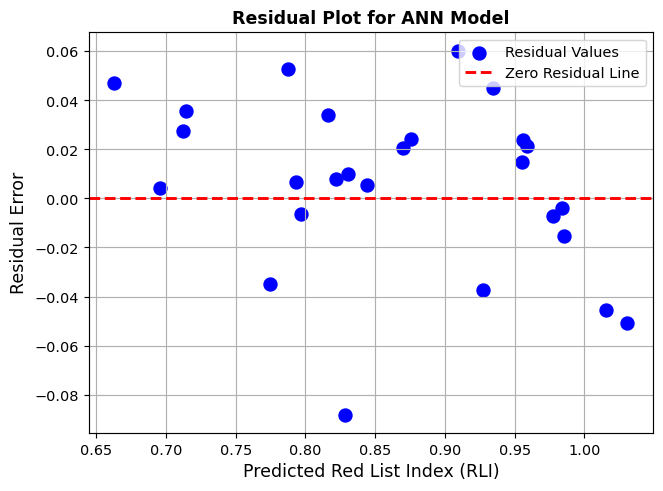

In [148]:
# ANN Residual Plot
residuals_ann = y_test - test_pred_ann
plt.figure(figsize=(7,5),dpi=104)
plt.scatter(test_pred_ann,residuals_ann,s=80,color="blue",label="Residual Values")
plt.axhline(y=0,color="red",linestyle="--",linewidth=2,label="Zero Residual Line")
plt.xlabel("Predicted Red List Index (RLI)",fontsize=12)
plt.ylabel("Residual Error",fontsize=12)
plt.title("Residual Plot for ANN Model",fontsize=12,fontweight="bold")
plt.legend()
plt.grid(True)
plt.show()

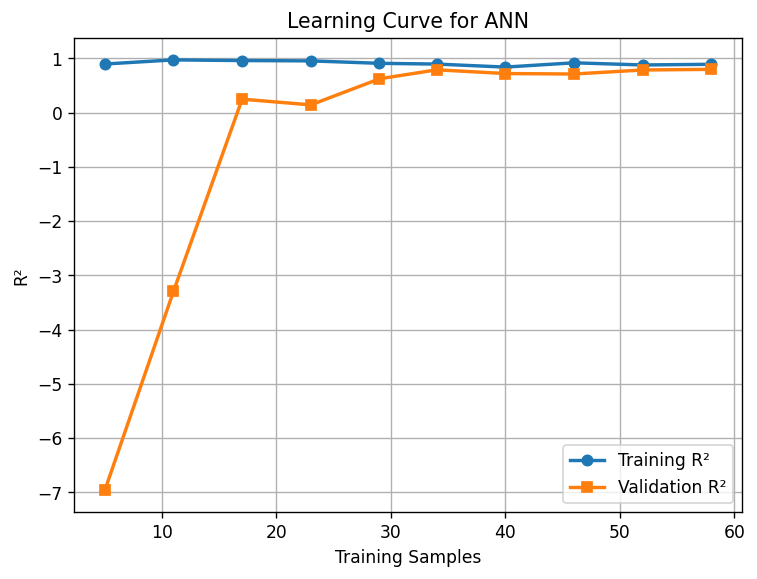

In [149]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt
sample_sizes, training_scores, validation_scores = learning_curve(ann,X_train_scaled,y_train,
    cv=3,scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10))
average_training_score = training_scores.mean(axis=1)
average_validation_score = validation_scores.mean(axis=1)
plt.figure(figsize=(7,5),dpi=123)
plt.plot(sample_sizes,average_training_score,marker="o",linewidth=2,label="Training R²")
plt.plot(sample_sizes,average_validation_score,marker="s",linewidth=2,label="Validation R²")
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Learning Curve for ANN")
plt.legend()
plt.grid(True)
plt.show()

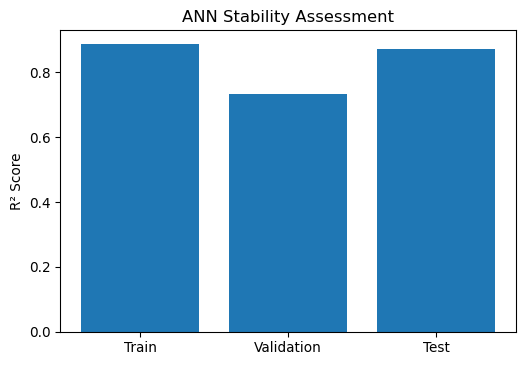

In [150]:
# ANN Stability Assessment
plt.figure(figsize=(6,4),dpi=98)
plt.bar(["Train","Validation","Test"],[ann_train_r2,ann_val_r2,ann_test_r2])
plt.ylabel("R² Score")
plt.title("ANN Stability Assessment")
plt.show()

In [151]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
configs = [
    ((2,), 0.03),
    ((2,), 0.05),
    ((4,), 0.05),
    ((8,), 0.05),
    ((16,), 0.05)
]
results = []
for layers, lr in configs:
    ann_model = MLPRegressor(hidden_layer_sizes=layers,activation='relu',solver='adam',
        alpha=0.01,learning_rate_init=lr,
        max_iter=450,)
    ann_model.fit(X_train_scaled, y_train)
    train_r2 = r2_score(y_train, ann_model.predict(X_train_scaled))
    val_r2 = r2_score(y_val, ann_model.predict(X_val_scaled))
    test_r2 = r2_score(y_test, ann_model.predict(X_test_scaled))
    results.append([layers, lr, train_r2, val_r2, test_r2])
for row in results:
    print(row)

[(2,), 0.03, 0.1569440606498511, -0.8100426990941687, -0.07776690592933244]
[(2,), 0.05, 0.09519348878671452, -0.46362969937123744, 0.1216445938067151]
[(4,), 0.05, -7.165138295175105, -13.885855961794126, -9.937440573134916]
[(8,), 0.05, 0.8583886463216366, 0.47756733627628434, 0.7489233538204962]
[(16,), 0.05, 0.6680540762120533, -0.09527620518042457, -0.13263663227367872]


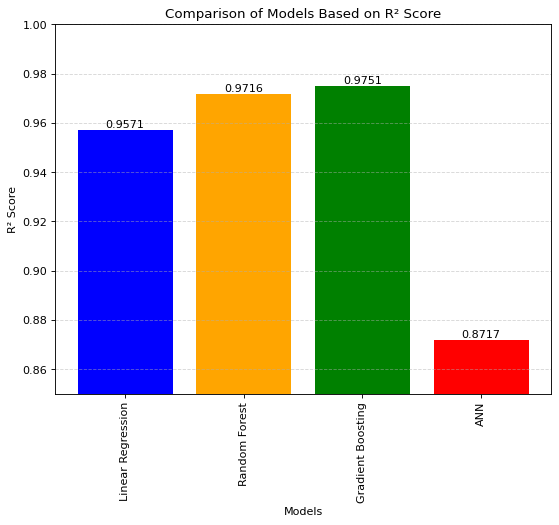

In [152]:
import matplotlib.pyplot as plt
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'ANN']
r2_scores = [0.9571, 0.9716, 0.9751, 0.8717]
colors = ['blue', 'orange', 'green', 'red']
plt.figure(figsize=(8,6),dpi=80)
bars = plt.bar(models, r2_scores, color=colors)
plt.ylabel('R² Score')
plt.xlabel('Models')
plt.title('Comparison of Models Based on R² Score')
plt.ylim(0.85, 1.00)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height + 0.001,f'{height:.4f}',ha='center')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

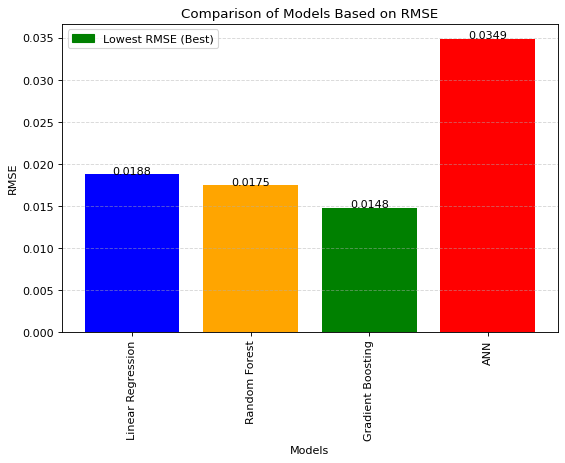

In [153]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
models = ["Linear Regression", "Random Forest", "Gradient Boosting", "ANN"]
rmse_scores = [0.0188, 0.0175, 0.0148, 0.0349]
colors = ["blue", "orange", "green", "red"]
plt.figure(figsize=(8,5), dpi=80)
bars = plt.bar(models, rmse_scores, color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center')
best_patch = mpatches.Patch(color='green', label='Lowest RMSE (Best)')
plt.legend(handles=[best_patch], loc='upper left')
plt.title("Comparison of Models Based on RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

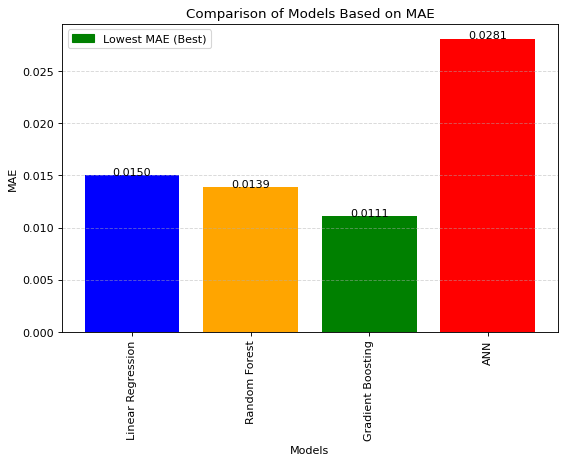

In [154]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
models = ["Linear Regression", "Random Forest", "Gradient Boosting", "ANN"]
mae_scores = [0.0150, 0.0139, 0.0111, 0.0281]
colors = ["blue", "orange", "green", "red"]
plt.figure(figsize=(8,5), dpi=80)
bars = plt.bar(models, mae_scores, color=colors)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height,f"{height:.4f}",ha='center')
best_patch = mpatches.Patch(color='green', label='Lowest MAE (Best)')
plt.legend(handles=[best_patch], loc='upper left')
plt.title("Comparison of Models Based on MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()